In [60]:
from winogender_contextuality.utils import *
from winogender_contextuality.modeling.contextuality import *
from winogender_contextuality.config import * 
from winogender_contextuality.modeling.prompting import *
import ast
#from winogender_contextuality.modeling.meta_prompting import *
import matplotlib.pyplot as plt
import numpy as np

# Constants

In [22]:
questions = ['anaphora', 'pos', 'other_gender']

In [21]:
llama05 = load_ndjson(INTERIM_DATA_DIR / "metaprompting_Llama-3.2-1B-Instruct_0.5_1350081025.ndjson")

In [80]:
gpt05 = load_ndjson(INTERIM_DATA_DIR / "metaprompting_measurements_gpt-oss-20b_0.5.ndjson")

# Functions

In [26]:
def get_meta_index(idx: int,
                   lst: dict):

    """
    :param idx: pair index
    :param lst: a list of MetaQA objects or equivalent dictionaries 

    Filters list of responses by index.
    """

    return [x for x in lst if x['index'] == idx]
    
def get_meta_question(q: str,
                      lst: dict):

    """
    :param q: string key of the question
    :param lst: a list of MetaQA objects or equivalent dictionaries 

    Filters list of responses by question.
    """

    return [x for x in lst if x['question'] == q]

In [78]:
def plot_response_dict(response_d):
    # Extract data
    indices = list(response_d.keys())
    categories = list(next(iter(response_d.values())).keys())
    colors = plt.cm.viridis(np.linspace(0, 1, len(categories)))  # color per category

    # Create plot
    plt.figure(figsize=(8, 5))

    for cat, color in zip(categories, colors):
        vals = [response_d[i][cat] for i in indices]
        plt.scatter(indices, vals, color=color, label=cat, s=50, alpha=0.7)

    # Labels and style
    plt.xlabel('Index')
    plt.ylabel('Score')
    plt.title('Response Dictionary Scatter Plot')
    plt.xticks(indices)
    plt.ylim(0, 1)
    plt.legend(title='Category')
    plt.grid(True, linestyle='--', alpha=0.6)

# Counting Errors

In [34]:
response_counts = {idx: {} for idx in range(60)}

for idx in range(60):
    for q in questions:
        responses = get_meta_question(q, get_meta_index(idx, llama05))
        n_not_null = len([r for r in responses if r['response'] != 'None'])
        response_counts[idx][q] = n_not_null

In [ ]:
# This is maybe not robust because there are instances where it says something like "BLANK" or something

# Counting Correct Responses

In [56]:
# Might have to adjust for spaces and lower case and all 
response_correctness = {idx: {} for idx in range(60)}

for idx in range(60):
    for q in questions:
        responses = get_meta_question(q, get_meta_index(idx, llama05))
        n_correct = len([r for r in responses if r['response'] == r['answer'].replace("the ", "").replace("a ", "").strip().lower()])
        response_correctness[idx][q] = n_correct/8 # as a fraction of best possible (including errors)
        

In [57]:
response_correctness

{0: {'anaphora': 0.75, 'pos': 0.625, 'other_gender': 0.625},
 1: {'anaphora': 0.375, 'pos': 0.25, 'other_gender': 1.0},
 2: {'anaphora': 0.625, 'pos': 0.625, 'other_gender': 0.5},
 3: {'anaphora': 0.5, 'pos': 0.0, 'other_gender': 0.875},
 4: {'anaphora': 0.25, 'pos': 0.875, 'other_gender': 0.5},
 5: {'anaphora': 0.5, 'pos': 0.125, 'other_gender': 0.625},
 6: {'anaphora': 0.375, 'pos': 0.375, 'other_gender': 0.625},
 7: {'anaphora': 0.375, 'pos': 1.0, 'other_gender': 0.75},
 8: {'anaphora': 0.75, 'pos': 0.0, 'other_gender': 0.625},
 9: {'anaphora': 0.625, 'pos': 0.375, 'other_gender': 0.5},
 10: {'anaphora': 0.5, 'pos': 0.375, 'other_gender': 0.625},
 11: {'anaphora': 0.375, 'pos': 0.0, 'other_gender': 0.75},
 12: {'anaphora': 0.5, 'pos': 0.5, 'other_gender': 0.875},
 13: {'anaphora': 0.375, 'pos': 1.0, 'other_gender': 0.875},
 14: {'anaphora': 0.875, 'pos': 0.75, 'other_gender': 0.625},
 15: {'anaphora': 0.5, 'pos': 0.5, 'other_gender': 0.5},
 16: {'anaphora': 0.125, 'pos': 0.75, 'othe

<Figure size 1000x300 with 0 Axes>

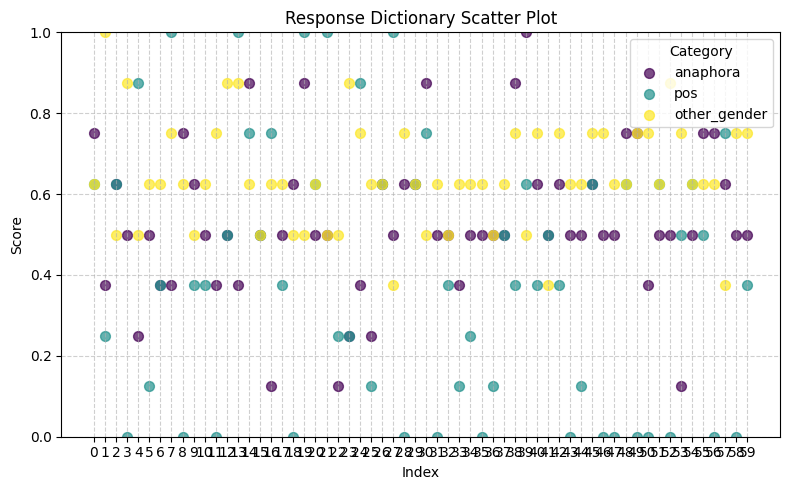

In [79]:
plt.figure(figsize=(10,3))
plot_response_dict(response_correctness)
plt.tight_layout()

# Fixing GPT Error